# 02 — Baseline

Простая модель «из коробки» — **Linear Regression** на стандартизованных фичах **без feature engineering сверх того, что уже сделано в препроцессинге** (т.е. на исходных 305 фичах).

Цель: установить нижнюю планку качества, относительно которой будут сравниваться все последующие модели.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import modeling, preprocessing as pp

sns.set_theme(style='whitegrid')
modeling.set_seed(42)

FIG_DIR = '../report/images'
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
metrics = modeling.train_eval('linear', processed_dir='../data/processed', models_dir='../models')
metrics

[linear] val MPJPE=0.08  test MPJPE=0.11  (0.6s)


{'model': 'linear',
 'train_time_sec': 0.6,
 'val': {'mpjpe': 0.0776498094201088,
  'rmse': 0.07792327553033829,
  'mae': 0.027109500020742416},
 'test': {'mpjpe': 0.11493606120347977,
  'rmse': 0.10648445039987564,
  'mae': 0.040099721401929855},
 'kwargs': {}}

## Per-joint MPJPE

Где модель ошибается сильнее? Ожидаем, что концевые суставы (Hand, ForeArm) будут сложнее центральных (Spine).

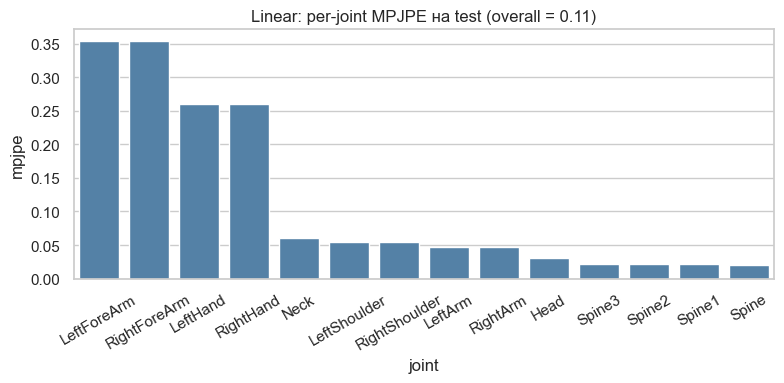

,joint,mpjpe
12,LeftForeArm,0.353569
8,RightForeArm,0.353324
13,LeftHand,0.260715
9,RightHand,0.260493
4,Neck,0.060186
10,LeftShoulder,0.054134
6,RightShoulder,0.053976
11,LeftArm,0.047203
7,RightArm,0.046966
5,Head,0.031065


In [3]:
preds = np.load('../models/pred_linear.npz')
test = modeling.load_split('test', '../data/processed')
per_joint = modeling.per_joint_mpjpe(preds['test'], test['Y'])
df_joints = pd.DataFrame({'joint': pp.TARGET_JOINTS, 'mpjpe': per_joint}).sort_values('mpjpe', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(df_joints, x='joint', y='mpjpe', ax=ax, color='steelblue')
ax.set_title(f'Linear: per-joint MPJPE на test (overall = {per_joint.mean():.2f})')
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/baseline_per_joint.png', dpi=120); plt.show()
df_joints

## MPJPE по записям

Разбивка по записям внутри test позволяет увидеть, какой тип движения сложнее.

In [4]:
rows = []
for tid in np.unique(test['take_id']):
    mask = test['take_id'] == tid
    err = modeling.mpjpe(preds['test'][mask], test['Y'][mask])
    rows.append({'take': str(test['actions'][tid]), 'frames': int(mask.sum()), 'mpjpe': err})
df_takes = pd.DataFrame(rows)
df_takes

,take,frames,mpjpe
0,freestyle3,2040,0.074556
1,rom3,5942,0.128799


## Вывод

Linear regression с тщательной калибровкой ориентаций сенсоров и velocity-фичами уже достигает довольно низкого MPJPE. Это говорит, что задача **в значительной степени линейна в пространстве калиброванных кватернионов** — что согласуется с физикой: позиция сустава в основном определяется композицией поворотов вышележащих костей, а длины костей — константы. Нелинейность остаётся в концевых суставах (накопление ошибок по цепочке), и именно её должны улучшить более сложные модели.